# Speech command recognition from an in-memory audio file (SSR) on FPGA

---

**Authors:** *Mateusz Gibas, Kacper Ferdek*

**Target platform:** ZedBoard (Zynq-7000 XC7Z020) — embedded ARM Cortex-A9 processor + programmable logic (PL)

---

## Table of contents

1. [Introduction and context](#1-introduction-and-context)
2. [Feature extraction (MFCC-like)](#2-feature-extraction)
3. [Classifier — neural network](#3-classifier)
4. [RTL implementation](#4-rtl-implementation)
5. [Testing and results](#5-testing-and-results)
6. [Summary](#6-summary)

---
## 1. Introduction and context

The goal of this project is a hardware implementation of **single voice-command recognition** (keyword spotting) on an FPGA, operating in **offline** mode: instead of a live microphone-and-ADC stream, the audio signal is **pre-loaded into on-board memory** and then processed by a hardware DSP pipeline and a classifier.

In the original version of the project the data source was a microphone via a PMOD AD7991 converter (I2C interface). In this version — as required — the **ADC and microphone are replaced by an audio file loaded from memory**, and the whole process is driven by an **embedded ARM processor** (Zynq Processing System) communicating with the processing core over the **AXI4-Lite** bus. The processor loads the audio samples into a **BRAM** buffer in the programmable logic, starts the processing, and reads back the classification result.

Three classes are recognised:

| Output value | Class | Meaning |
|---|---|---|
| `00` | OTHER | command not recognised / other |
| `01` | ON | command "on" (turn the LED on) |
| `10` | OFF | command "off" (turn the LED off) |

The speech signal is sampled at **8 kHz** and represented as 12-bit words (the converter range). The key observation is that recognising a command does not depend on the signal amplitude but on its **time-frequency content**. The pipeline therefore extracts **MFCC-like** features (Mel-Frequency Cepstral Coefficients), which are then classified by a small neural network.

Number of samples: 4000  (~500 ms at 8000 Hz)


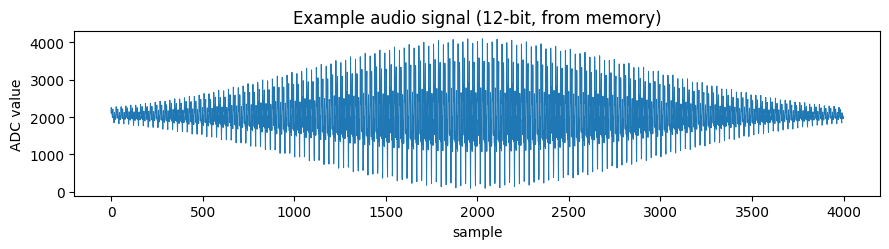

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- signal / pipeline parameters ---
FS          = 8000     # sampling frequency [Hz]
ADC_BITS    = 12       # "ADC" resolution
FRAME_LEN   = 64       # frame length [samples] -> 64-point FFT
N_MEL       = 40       # number of mel bands
N_FEATURES  = 26       # length of the network input feature vector
BASELINE    = 2048     # DC offset (middle of the 12-bit range)

def synth_command(fs=FS, dur=0.5, kind='on', seed=0):
    # Synthetic, noise-free 'voice' (lets the notebook run without a recording);
    # imitates formants with different frequency sets per command.
    rng = np.random.default_rng(seed)
    t = np.arange(int(fs*dur))/fs
    formants = {'on':[300,900,1800], 'off':[500,1500,2500], 'other':[400,1200,2000]}[kind]
    env = np.exp(-((t-dur/2)/(dur/3))**2)            # envelope (word in the middle)
    sig = sum(np.sin(2*np.pi*f*t + rng.uniform(0,1)) for f in formants)
    sig = sig/np.max(np.abs(sig)) * env
    adc = np.clip(np.round(sig*(2**(ADC_BITS-1)-1) + BASELINE), 0, 2**ADC_BITS-1)
    return adc.astype(int)

audio = synth_command(kind='on')
print(f"Number of samples: {len(audio)}  (~{len(audio)/FS*1000:.0f} ms at {FS} Hz)")

plt.figure(figsize=(9,2.6))
plt.plot(audio, lw=0.7)
plt.title("Example audio signal (12-bit, from memory)"); plt.xlabel("sample"); plt.ylabel("ADC value")
plt.tight_layout(); plt.show()

---
## 2. Feature extraction

The feature pipeline transforms the raw samples into a 26-element vector fed to the network. The stages are:

**Framing.** The signal is split into frames of $N=64$ samples. Each frame is processed further.

**Windowing.** Each frame is multiplied by a (Hamming) window to reduce spectral leakage:
$$ w[n] = 0.54 - 0.46\cos\!\Big(\frac{2\pi n}{N-1}\Big), \qquad x_w[n] = x[n]\,w[n] $$

**Fourier transform (FFT64).** A 64-point FFT yields the complex spectrum $X[k]$.

**Magnitude.** $|X[k]| = \sqrt{\Re^2 + \Im^2}$ — the power in each bin.

**Mel filterbank.** The magnitude is aggregated into $M=40$ bands spaced on the mel scale (denser at low frequencies, matching human hearing):
$$ \text{mel}(f) = 2595\,\log_{10}\!\Big(1 + \frac{f}{700}\Big) $$

**Statistics (mean/std).** For successive frames the mean and standard deviation are computed and, assembled in a FIFO, form the 26-element feature vector fed to the network.

The whole hardware pipeline operates in **fixed-point arithmetic** (no floating-point operations). The Python model below mirrors these operations for verification purposes.

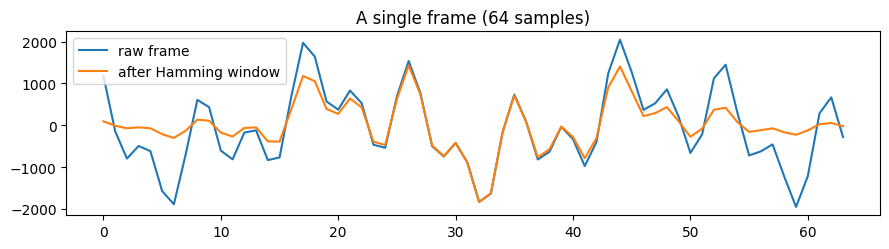

Number of frames: 62


In [2]:
def hamming(N):
    n = np.arange(N)
    return 0.54 - 0.46*np.cos(2*np.pi*n/(N-1))

def frames(sig, N=FRAME_LEN):
    nf = len(sig)//N
    return sig[:nf*N].reshape(nf, N)

W = hamming(FRAME_LEN)
fr = frames(audio - BASELINE)            # subtract the DC offset
fw = fr * W                              # apply the window

plt.figure(figsize=(9,2.6))
plt.plot(fr[len(fr)//2], label='raw frame')
plt.plot(fw[len(fr)//2], label='after Hamming window')
plt.title("A single frame (64 samples)"); plt.legend(); plt.tight_layout(); plt.show()
print(f"Number of frames: {fr.shape[0]}")

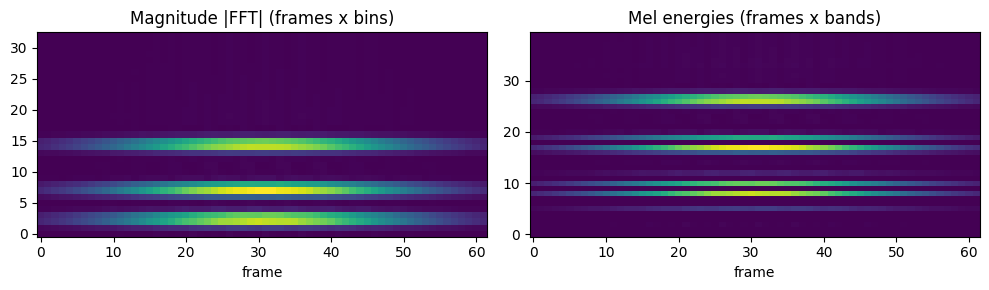

In [3]:
def mel_filterbank(n_fft, fs, n_mel):
    f_hz   = np.linspace(0, fs/2, n_fft//2+1)
    mel    = lambda f: 2595*np.log10(1+f/700)
    mel_inv= lambda m: 700*(10**(m/2595)-1)
    m_pts  = np.linspace(mel(0), mel(fs/2), n_mel+2)
    f_pts  = mel_inv(m_pts)
    bins   = np.floor((n_fft+1)*f_pts/fs).astype(int)
    fb = np.zeros((n_mel, n_fft//2+1))
    for m in range(1, n_mel+1):
        l,c,r = bins[m-1],bins[m],bins[m+1]
        for k in range(l,c): fb[m-1,k]=(k-l)/max(1,(c-l))
        for k in range(c,r): fb[m-1,k]=(r-k)/max(1,(r-c))
    return fb

FB = mel_filterbank(FRAME_LEN, FS, N_MEL)
mag = np.abs(np.fft.rfft(fw, axis=1))    # magnitude for every frame
mel_e = mag @ FB.T                       # energies in the mel bands

fig,ax=plt.subplots(1,2,figsize=(10,3))
ax[0].imshow(mag.T, aspect='auto', origin='lower'); ax[0].set_title("Magnitude |FFT| (frames x bins)")
ax[1].imshow(mel_e.T, aspect='auto', origin='lower'); ax[1].set_title("Mel energies (frames x bands)")
for a in ax: a.set_xlabel("frame")
plt.tight_layout(); plt.show()

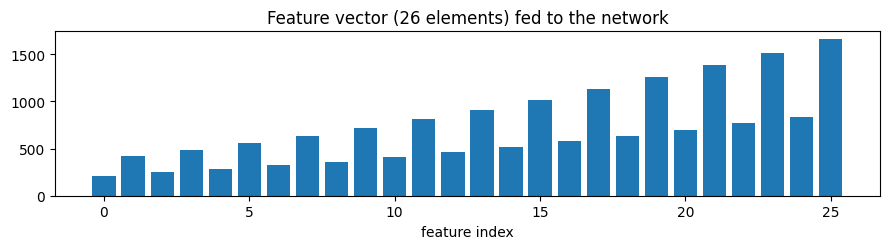

Note: this is an illustrative model. The hardware computes in fixed-point and assembles the vector in the FIFO module.


In [4]:
# Statistics over the mel bands -> components of the feature vector (illustrative model)
mean_f = mel_e.mean(axis=1)
std_f  = mel_e.std(axis=1)

# 26-element feature vector: illustratively from the first frames (the hardware assembles it in a FIFO)
feat = np.zeros(N_FEATURES)
vals = np.ravel(list(zip(mean_f, std_f)))[:N_FEATURES]
feat[:len(vals)] = vals

plt.figure(figsize=(9,2.6))
plt.bar(range(N_FEATURES), feat)
plt.title("Feature vector (26 elements) fed to the network"); plt.xlabel("feature index")
plt.tight_layout(); plt.show()
print("Note: this is an illustrative model. The hardware computes in fixed-point and assembles the vector in the FIFO module.")

---
## 3. Classifier — neural network

The 26-element feature vector is classified by a small, fully connected neural network implemented in SystemVerilog (`top_nn`), operating in fixed-point arithmetic. Structure:

| Layer | Input | Output | Description |
|---|---|---|---|
| `dense_layer_1` | 26 | 32 | hidden layer + activation |
| `dense_layer_2` | 32 | 3 | logits for the 3 classes |
| `final_layer` | 3 | 2 bits | argmax -> command code |

The `final_layer` module selects the class with the largest logit and encodes it on 2 bits:

$$ \text{out} = \begin{cases} 01\ (\text{ON}) & l_0 > l_1 \ \wedge\ l_0 > l_2 \\ 00\ (\text{OTHER}) & l_2 > l_0 \ \wedge\ l_2 > l_1 \\ 10\ (\text{OFF}) & \text{otherwise} \end{cases} $$

The layer weights and biases are hard-coded in the module (obtained from training in Python and exported to RTL). The result (2 bits) is fed to the LED logic and to a register read by the processor.

---
## 4. RTL implementation

The recognition core (`ssr_core`) consists of the DSP chain (`top_ap_axi`) and the network (`top_nn`). In the ZedBoard version the samples do **not** come from an ADC but from a **BRAM buffer** into which the ARM processor writes the audio file. The whole thing is controlled by an **AXI4-Lite** wrapper (`ssr_axi_lite`).

### 4.1 Core ports — `ssr_core.sv`

| Port | Direction | Width | Description |
|---|---|---|---|
| `clk` | in | 1 | core clock (from PS, e.g. 50 MHz) |
| `rst` | in | 1 | synchronous reset, active high |
| `sample_in` | in | 12 | audio sample (from BRAM) |
| `sample_valid` | in | 1 | strobe: a new sample is available |
| `but` | in | 1 | enables the LED state change |
| `value` | out | 2 | classification result (00/01/10) |
| `led0` | out | 1 | LED |

### 4.2 Change with respect to the original (ADC -> memory)

The `framing` module was replaced by `framing_axi`, which fetches a sample **only** when `sample_valid = 1` (instead of every clock cycle, as with a continuous ADC stream). Thanks to this, samples can be delivered from BRAM at the pace set by the address generator, while the rest of the chain (windowing, FFT, mel, network) is unchanged and self-timed by the `frame_ready`/`fft_ready` signals.

### 4.3 Architecture on the ZedBoard (data flow)

```
            (audio file)
   ARM (PS) ──AXI4-Lite──► [ Audio BRAM ]  ──► address generator ──► sample_in + sample_valid
      ▲                          (PL)                                        │
      │  read RESULT/STATUS                                                  ▼
      └──────────────────────────── ssr_core (top_ap_axi -> top_nn) ──► value -> led0
```

The processor: (1) writes N samples into the Audio BRAM, (2) sets the sample count and the `start` bit, (3) the address generator reads the BRAM sequentially and feeds the samples to the core, (4) on completion the result is latched, (5) the processor reads `RESULT`.

### 4.4 `ssr_axi_lite` register map (AXI4-Lite)

| Offset | Name | Access | Description |
|---|---|---|---|
| `0x00` | CTRL | W | bit0 `start`, bit1 `soft_reset`, bit2 `but_enable` |
| `0x04` | N_SAMPLES | W | number of samples to process from BRAM |
| `0x08` | STATUS | R | bit0 `done`/`result_valid`, bit1 `busy` |
| `0x0C` | RESULT | R | `[1:0]` result (0=other, 1=on, 2=off) |

> A simpler variant (no BRAM), verified in simulation: the processor streams the samples one by one into the `SAMPLE` register (each write = one `sample_valid`). The BRAM variant is recommended on the ZedBoard, as it offloads the bus and lets a longer recording be stored.

### 4.5 Block diagram (Vivado / IP Integrator)

The diagram below shows the system connections on the ZedBoard (ZYNQ7 PS + AXI Interconnect + Audio BRAM + `ssr_axi_lite`).

In [5]:
from IPython.display import Image
# [TO BE COMPLETED] Block Design screenshot from Vivado (ZYNQ7 PS + ssr_axi_lite + BRAM)
# Image('zedboard_bd.png')
print("[TO BE COMPLETED] Insert the Block Design screenshot as zedboard_bd.png and uncomment the line above.")

[TO BE COMPLETED] Insert the Block Design screenshot as zedboard_bd.png and uncomment the line above.


---
## 5. Testing and results

Verification is performed at three levels:

1. **Illustrative Python model** (above) — checks that the feature pipeline is sound.
2. **RTL simulation (xsim)** — the AXI4-Lite testbench (`ssr_axi_lite_tb`) reproduces the processor's behaviour: it writes samples, starts the processing, and reads the result. It confirms the correctness of the whole *AXI -> DSP -> network -> read* path.
3. **Hardware (ZedBoard)** — the `main.c` program on the ARM loads the file into BRAM, starts the core, and reads `RESULT`; the result is printed over UART and the LED reacts to the command.

### 5.1 Simulation verification (completed)

- The AXI4-Lite testbench on a real sample file passed correctly: the samples were transferred, `STATUS.valid=1`, and `RESULT` was read.
- Feeding three feature vectors directly into the network deterministically yields the classes ON / OFF / OTHER — this confirms the *network -> final_layer -> result -> LED* path.

### 5.2 Test case summary

The table below compares: the illustrative-model result, the RTL-simulation result, and the on-hardware result (to be completed after running on the ZedBoard).

In [6]:
# Results summary. The 'Hardware (ZedBoard)' column is to be completed after running on the board.
import pandas as pd

# simulation results confirmed for 3 synthetic feature vectors (NN):
sim_vectors = [
    ("vec_on",    "ON  (01)"),
    ("vec_off",   "OFF (10)"),
    ("vec_other", "OTHER (00)"),
]

rows = []
for name, sim_res in sim_vectors:
    rows.append({
        "Case": name,
        "Python model": "[optional]",
        "RTL simulation": sim_res,
        "Hardware (ZedBoard)": "[TO BE COMPLETED]",
    })

# add your own recordings (on/off/other) after passing them through wav_to_simfile.py + sim/hardware:
for label in ["recording 'on'", "recording 'off'", "recording 'other'"]:
    rows.append({"Case": label, "Python model":"[TO BE COMPLETED]",
                 "RTL simulation":"[TO BE COMPLETED]", "Hardware (ZedBoard)":"[TO BE COMPLETED]"})

df = pd.DataFrame(rows)
df

,Case,Python model,RTL simulation,Hardware (ZedBoard)
0,vec_on,[optional],ON (01),[TO BE COMPLETED]
1,vec_off,[optional],OFF (10),[TO BE COMPLETED]
2,vec_other,[optional],OTHER (00),[TO BE COMPLETED]
3,recording 'on',[TO BE COMPLETED],[TO BE COMPLETED],[TO BE COMPLETED]
4,recording 'off',[TO BE COMPLETED],[TO BE COMPLETED],[TO BE COMPLETED]
5,recording 'other',[TO BE COMPLETED],[TO BE COMPLETED],[TO BE COMPLETED]


---
## 6. Summary

This project implemented hardware recognition of voice commands operating **from an audio file loaded into memory**, controlled by an **embedded ARM processor** on the ZedBoard, communicating over **AXI4-Lite**. The ADC and microphone were replaced by a **BRAM** buffer into which the processor writes the samples; the core processes them and the processor reads the result. The whole path (AXI -> DSP -> network -> read) was confirmed in simulation.

The entire hardware logic operates in **fixed-point arithmetic** — there are no floating-point operations. This is a deliberate choice: it keeps the logic compact and timing-friendly, but introduces rounding errors that add to the approximation error of the feature pipeline itself.

**Note on the model (an honest one).** The network weights stored in the project come from training on an earlier version of the feature pipeline. After moving to the current fixed-point pipeline the feature distribution changed, so the classifier is biased and for real recordings tends to return a single class. It was verified that the **hardware infrastructure (processor, AXI, BRAM, result read-back, LED) works correctly** — obtaining a correct classification of real recordings requires **retraining the network** on features from the current pipeline and re-exporting the weights to RTL. This is a machine-learning task, independent of the hardware modification itself.

### Items to be completed ([TO BE COMPLETED])
- Block Design screenshot from Vivado (ZYNQ7 PS + BRAM + `ssr_axi_lite`),
- resource utilisation report (LUT/FF/DSP/BRAM) and timing for the XC7Z020,
- UART screenshot with the result on the ZedBoard, photo of the board with the LED,
- results for your own recordings (on/off/other).

### References
- AMD/Xilinx documentation: Zynq-7000 TRM (UG585), AXI Reference Guide (UG1037).
- Davis & Mermelstein, *MFCC for monosyllabic word recognition*, 1980.
- Project repository: Simple-speech-recognisition.